# Recurrent Neural Networks (RNN)

RNNs are designed to understand sequences, where the order of things matters. A Recurrent Neural Network (RNN) is a neural network designed to process things that unfold over time (or in a sequence in general)

Ordinary neural networks look at everything all at once. But time-structured data arrives step by step.

The code idea behind RNNs is:
> The network keeps a memory of the past and updates it as new input arrives.

This memory is what we call **the hidden state** in RNN jargon. 

- At time 1, the model sees something → updates its memory
- At time 2, it sees something new → updates the same memory
- At time 3, same thing

And so on

The network does not restart at each step. That’s what makes it recurrent.

Think of it like this: when you are hearing a sentence, you do not immediately forget the first word. To get a full understanding of the sentence you need to keep track of the words as you hear them and update your understanding of the meaning of the sentence as words come in. This is exactly what the RNN is doing. 

The hidden state is not the past itself — it’s a compressed summary of the past.

Now the math behind it: 

At each time step t:
$$h_t = f(x_t, h_{t-1})$$
- $x_t$: input at time t
- $h_t$: hidden state at time t 
	​

more precisely:
$$ h_t = \phi(W_hh_{t-1} + W_xx_t + b)$$

where $\phi$ is usally something like $tanh$ so we have: $ h_t = tanh(W_hh_{t-1} + W_xx_t + b)$

- $W_hh_{t-1}$: how much the past matters
- $W_xx_t$: how much the present matters
- b: bias
- $tanh$ is supposed to keep the values from blowing up.

It is called recurrent because at each stage, the output of the model is fed back to itself (present becomes past. Memory is updated based on what the model sees now)

It is important to note that:
An RNN is not:
- a storage of all past inputs
- a database
- a time-stamped memory

It is:
- a dynamic system that evolves over time

h = 0

for x in sequence:
    h = f(h, x)


## recurrence
The internal state of the model at time t - 1 influences the internal state at time t. The model keep updating its internal/hidden state over time

simply: new state=f(**old state**,new input)

## Hidden states: 
In RNNs, hidden state is the model’s internal memory at a particular moment in time.

An RNN has one internal memory space with a fixed size.  $h_t \in \mathbb{R}^{\text{hidden\_dim}}$ 

and so everything that influences the memory (or is used in updating the memory) will have to be in the same space with the same dimension. And because the update happens in the memory:
So we project:

- input → hidden space
- previous hidden → hidden space


## 

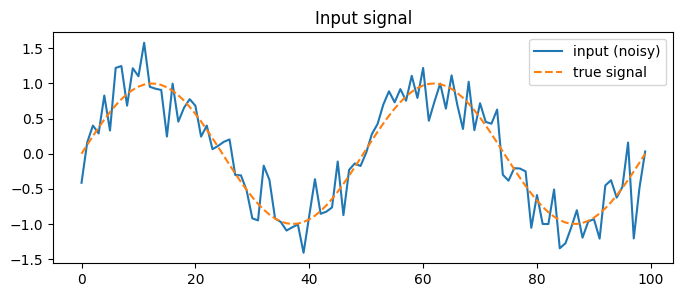

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# simulate a signal
T = 100                      # number of time steps
t = np.linspace(0, 4*np.pi, T)

x = np.sin(t)                # clean signal
x_noisy = x + 0.3 * np.random.randn(T)  # noisy input

plt.figure(figsize=(8, 3))
plt.plot(x_noisy, label="input (noisy)")
plt.plot(x, label="true signal", linestyle="--")
plt.legend()
plt.title("Input signal")
plt.show()


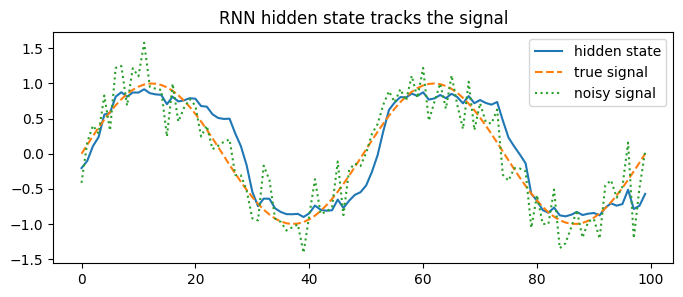

In [2]:
# Without any training, we simulate the function that the RNN is trying to implement
# RNN parameters (scalars!)
w_h = 0.9     # memory weight (past)
w_x = 0.5     # input weight (present)
b   = 0.0     # bias

def rnn_step(h_prev, x_t):
    return np.tanh(w_h * h_prev + w_x * x_t + b)


h = np.zeros(T)   # hidden state over time
h_prev = 0.0      # initial memory

for t in range(T):
    # This loop is recurrence
    # The same function is reused at every time step
    # The only thing that carries forward is h_prev
    h[t] = rnn_step(h_prev, x_noisy[t])
    h_prev = h[t]


# The hidden state is not the input.
# It’s a filtered, memory-based estimate of the input.
plt.figure(figsize=(8, 3))
plt.plot(h, label="hidden state")
plt.plot(x, linestyle="--", label="true signal")
plt.legend()
plt.plot(x_noisy, linestyle=":", label="noisy signal")
plt.legend()
plt.title("RNN hidden state tracks the signal")
plt.show()



- the hidden state is smoother than the actual noisy signal
- the hidden state is lagging with respect to the original noisy signal


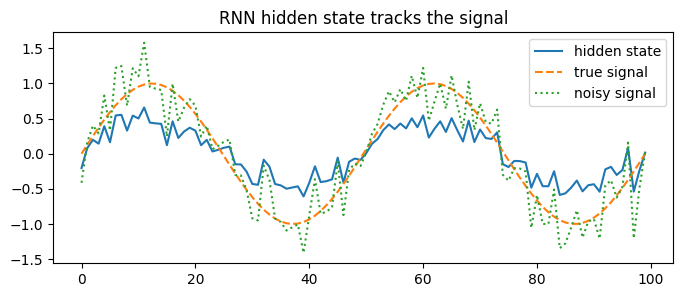

In [3]:
# now let's take a look at the role of the memory. 
# to look at the effect of memory, we set the w_h which is the weight of the previous states to 0
# Without any training, we simulate the function that the RNN is trying to implement
# RNN parameters (scalars!)
w_h = 0       # memory weight (past)
w_x = 0.5     # input weight (present)
b   = 0.0     # bias

def rnn_step(h_prev, x_t):
    return np.tanh(w_h * h_prev + w_x * x_t + b)


h = np.zeros(T)   # hidden state over time
h_prev = 0.0      # initial memory

for t in range(T):
    # This loop is recurrence
    # The same function is reused at every time step
    # The only thing that carries forward is h_prev
    h[t] = rnn_step(h_prev, x_noisy[t])
    h_prev = h[t]


# The hidden state is not the input.
# It’s a filtered, memory-based estimate of the input.
plt.figure(figsize=(8, 3))
plt.plot(h, label="hidden state")
plt.plot(x, linestyle="--", label="true signal")
plt.legend()
plt.plot(x_noisy, linestyle=":", label="noisy signal")
plt.legend()
plt.title("RNN hidden state tracks the signal")
plt.show()



- The hidden state now tracks the input instantaneously
- No temporal smoothing
- No memory

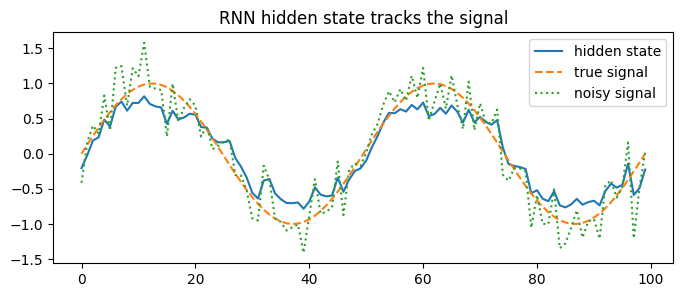

In [4]:
# Without any training, we simulate the function that the RNN is trying to implement
# RNN parameters (scalars!)
w_h = 0.5     # memory weight (past)
w_x = 0.5     # input weight (present)
b   = 0.0     # bias

def rnn_step(h_prev, x_t):
    return np.tanh(w_h * h_prev + w_x * x_t + b)


h = np.zeros(T)   # hidden state over time
h_prev = 0.0      # initial memory

for t in range(T):
    # This loop is recurrence
    # The same function is reused at every time step
    # The only thing that carries forward is h_prev
    h[t] = rnn_step(h_prev, x_noisy[t])
    h_prev = h[t]


# The hidden state is not the input.
# It’s a filtered, memory-based estimate of the input.
plt.figure(figsize=(8, 3))
plt.plot(h, label="hidden state")
plt.plot(x, linestyle="--", label="true signal")
plt.legend()
plt.plot(x_noisy, linestyle=":", label="noisy signal")
plt.legend()
plt.title("RNN hidden state tracks the signal")
plt.show()



This RNN:

- integrates information over time
- smooths noisy signals
- maintains an internal state

## The inductive biases

Definition of inductive bias: the assumptions a model makes before seeing any data. An inductive bias is the set of preferences a model has about what kinds of solutions are likely, built into its structure.

what are those built-in preferences here:

Let's take a look at the equation again:

$ h(t) = tanh(W_hh_{t-1} + W_xx(t) + b)$ 
- bias #1: time matters! What happened just before now is relevant to what happens now.
- bias #2: RNN does not store the full history
- bias #3: recent past matters more: The world has temporal continuity and decay. 
- bias #4: the dynamics are smooth (tanh)
- bias #5: Weight sharing: the same $W_h$ and $W_x$ and function (tanh in this example) are used for all the time steps

__The RNN didn’t learn to smooth the signal. It was built to smooth the signal.__

In [5]:
import torch
import torch.nn as nn

class myRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # this is where you define the architecture
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        # we use the classic update rule here:
        # h(t) = tanh(W_h*h(t-1) + W_x*x(t) + b)
        # in this update rule, W_h and W_x are learnable weights
        # which by definition (as inductive biases) remain constant over time
        # you can think of W_h and W_x as learnable affine transformations
        # NOTE that the RNN has only one internal memory space
        # and so anything that influences the memory must be in that internal memory space
        # --- Learnable weights for the update rule ---
        self.W_x = nn.Linear(input_dim, hidden_dim, bias=True)
        # W_x corresponds to the term W_x x_t + b in the math.
        # It tells the model how the current input affects memory.

        self.W_h = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # W_h corresponds to the term W_h h_{t-1}.
        # It tells the model how previous memory influences new memory.
        # We set bias=False here so we don't add the bias twice
        # (we already have bias in W_x).

        # it is also important to NOTE that W_x and W_h are defined as nn.Linear
        # which means they are not just a matrix
        # What is happening under the hood? for W_x
        # x_t @ W_x.weight.T + W_x.bias
        # and for self.W_h:
        # h_t @ W_h.weight.T (bias is set to False here)

        self.nonlinearity = torch.tanh
        # This is the tanh(·) in the RNN equation.
        # It keeps the hidden state bounded and introduces nonlinearity.

        # --- Learnable weights for producing outputs from hidden state ---
        self.W_y = nn.Linear(hidden_dim, output_dim, bias=True)
        # This is the readout: y_t = W_y h_t + b_y.
        # Important: the recurrence is in h_t, not y_t.
        # y_t is just what we want the model to report.

        # alternatively, we could have defined these using nn.Parameter
        # when you use nn.Linear, there are Parameters inside. In other words, 
        # nn.Linear is a container that will contain parameters
        # when we use nn.Parameter, we should also initialize them
        # on the other hand, using nn.Linear, the initialization is done automatically
        # self.W_x = nn.Parameter(torch.randn(self.input_dim, self.hidden_dim))
        # self.W_h = nn.Parameter(torch.randn(self.hidden_dim, self.hidden_dim))
        # self.b_h = nn.Parameter(torch.zeros(self.hidden_dim))

    def forward(self, x: torch.Tensor, h0: torch.Tensor | None = None):
        """
        x_seq:  Tensor of shape [batch, time, input_dim]
        h0: Optional initial hidden state of shape [batch, hidden_dim]

        Returns:
            y:  Tensor of shape [batch, time, output_dim]
            h:  Tensor of shape [batch, time, hidden_dim]  (all hidden states)
        """

        B, T, D = x.shape
        # B is batch size, T is time, D is input dim
        # NOTE that D must be equal to self.input_dim
        # you can raise an error here if that is not the case

        if D != self.input_dim:
            raise ValueError(f"Expected input_dim={self.input_dim}, got {D}")
        
        # --- Initialize hidden state (memory) ---
        if h0 is None:
            h_t = torch.zeros(B, self.hidden_dim, device=x.device, dtype=x.dtype)
            # If we don't provide an initial memory, start with zeros.
            # Conceptually: "the model begins with no information."

        else:
            # If provided, we start from a chosen initial memory state.
            h_t = h0

        h_all = []
        y_all = []
        # We'll store the hidden state and output at every time step
        # so we can visualize them and/or compute losses across time.

        # now the rollout begins
        # the recurrence happens in this loop (look we are rolling out)
        for t in range(T):
            # first get the x at time t
            x_t = x[:, t, :]
            # x_t is the input at time t for all sequences in the batch.
            # Shape: [B, input_dim]

            # now the update rule
            # NOTE this is our update rule: h(t) = tanh(W_h*h(t-1) + W_x*x(t)+b)
            # NOTE that self.W_x(x_t) is equivalent to writing:
            # W_x@x_t + b
            # Whenever you see layer(x), read it as: multiply by a matrix, add a bias.
            h_t = self.nonlinearity(self.W_h(h_t) + self.W_x(x_t))
            # This line directly matches:
            #   h_t = tanh(W_x x_t + W_h h_{t-1} + b)
            #
            # Key conceptual points:
            # 1) MEMORY: h_t depends on previous h_t (which is h_{t-1})
            # 2) RECURRENCE: we feed the hidden state forward in time
            # 3) WEIGHT SHARING: self.W_x and self.W_h are the SAME objects
            #    used for every t (same parameters reused at every step)

            # append it to h_all to keep track of it
            h_all.append(h_t)

            # now the output
            y_t = self.W_y(h_t)
            # Output readout. This does NOT feed back by default.
            # The "recurrent" part is h_t -> next h_t.

            # append it to y_all
            y_all.append(y_t)

        # Stack lists into tensors:
        h = torch.stack(h_all, dim=1)  # [B, T, hidden_dim]
        y = torch.stack(y_all, dim=1)  # [B, T, output_dim]
        return y, h
    

B, T, input_dim = 4, 10, 1
hidden_dim, output_dim = 8, 1

model = myRNN(input_dim, hidden_dim, output_dim)
x = torch.randn(B, T, input_dim)

y, h = model(x)
print("y:", y.shape)  # [4, 10, 1]
print("h:", h.shape)  # [4, 10, 8]


y: torch.Size([4, 10, 1])
h: torch.Size([4, 10, 8])


In [6]:
# a simple example.
# the goal is to predict the next value of a 1D signal
# we have a noisy sinosuidal X and Y contains the next state
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

# Create sine wave data
T = 100
t = np.linspace(0, 8*np.pi, T)
signal = np.sin(t)

# Add noise
signal_noisy = signal + 0.2 * np.random.randn(T)

# Convert to tensors
x = torch.tensor(signal_noisy[:-1], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
y = torch.tensor(signal_noisy[1:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)


Let's take a look at the model predictions without any training

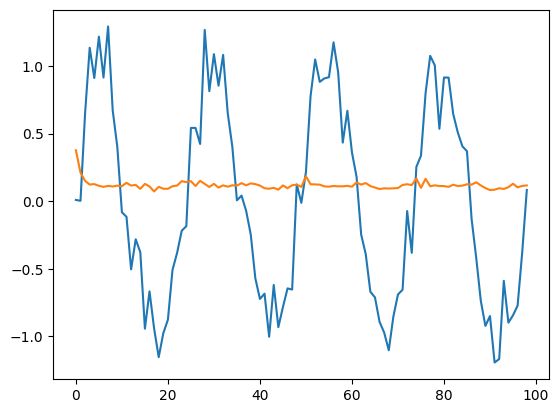

In [7]:
# now create an instance of myRNN. 
# you need input_dim, hidden_dim, and output_dim
x.shape
y.shape
input_dim = 1
output_dim = 1

RNN_new = myRNN(hidden_dim=32, input_dim=1, output_dim=1)
y_pred, h = RNN_new.forward(x)
# convert y_pred to numpy 

plt.plot(y[0, :, 0])
plt.plot(y_pred.detach().numpy()[0,:, 0])

Not so good! Now we train the model! For training, like before, we need to define a loss function and an optimizer

In [8]:
import torch.optim as optim
model = myRNN(input_dim=1, hidden_dim=32, output_dim=1)
# we will use an adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# now the loss function: we use a simple MSE
loss_fn = nn.MSELoss()

loss_all = []
for epoch in range(500): 
    # first clear out all the grad values
    # clear out gradients
    # if you don't do this, the grad is gonna accumulate(The new gradients are added on top of the old ones.)
    # Gradients grow larger and larger.
    # general rule: when you are training, the first thing you do is always to clear out the gradients
    # run the model and get the predictions
    # calculate the current loss
    # backprop (backward)
    # update the parameters
    # 
    optimizer.zero_grad() # comment out to see the effect
    # run the model once
    # you can alternatively do: y_pred, h = model(x)
    y_pred, h = model.forward(x)

    # calculate the loss
    current_loss = loss_fn(y_pred, y)

    # run backprop
    current_loss.backward()

    loss_all.append(current_loss.item())
    # update the parameters
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {current_loss.item():.4f}")



Epoch 0, Loss: 0.5319
Epoch 50, Loss: 0.0408
Epoch 100, Loss: 0.0309
Epoch 150, Loss: 0.0231
Epoch 200, Loss: 0.0179
Epoch 250, Loss: 0.0149
Epoch 300, Loss: 0.0075
Epoch 350, Loss: 0.0045
Epoch 400, Loss: 0.0042
Epoch 450, Loss: 0.0020


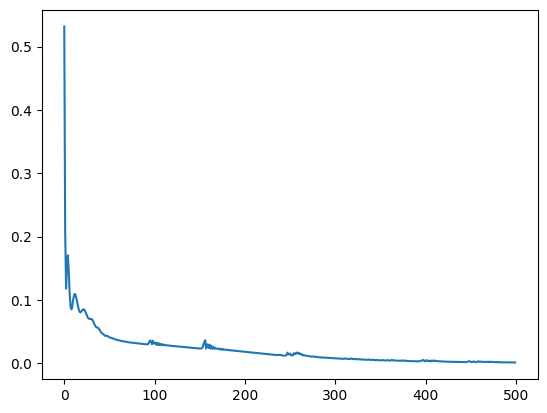

In [9]:
plt.plot(loss_all)

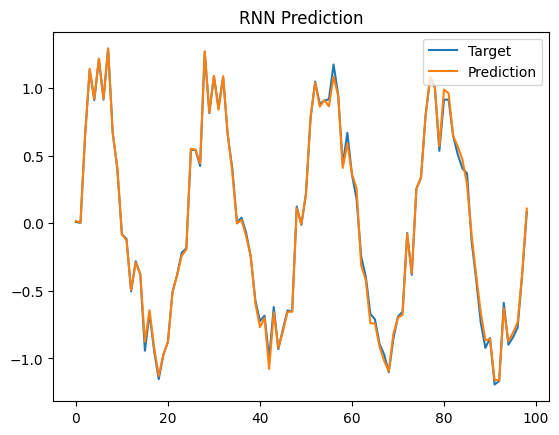

In [10]:
with torch.no_grad():
    pred, h = model(x)
    pred = pred.detach().numpy()

plt.plot(signal_noisy[1:], label="Target")
plt.plot(pred[0, :, 0], label="Prediction")
plt.legend()
plt.title("RNN Prediction")
plt.show()


## Long term memory
The example above was pretty simple! You just need to predict the next value in a sequence. Now let's consider another example where RNN can be used. 

Assume a sequence of numbers are said out loud, the first four digits are the PIN which you/model need to memorize. The rest of the numbers are basically noise. 

Input:
$$ x_1, x_2, x_3, ..., x_N$$

Output:

$$ y = Pin Digits $$

The PIN digits appear early in the sequence.
The model sees them, then sees noise, and at the end must output them.

So this is NOT a forecasting task. It is a: Sequence → summary task.

so if the pin digits length is considered to be T, then the model is learning, as usual, a function:
$f(x_{1:T}) = PIN$

That function must:
1. Detect relevant inputs early
2. Encode them into hidden state (the internal memory)
3. Protect that representation from noise
4. Decode it at the end

In [ ]:
# now first let's define a function that spills out the sequences
# Early time steps: meaningful signal
# Later time steps: irrelevant distraction
# Target: recall early digits
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

def generate_pin_sequence(seq_len=50, pin_length=4):
    """
    Generates a sequence with a 4-digit PIN embedded early,
    followed by noise.

    Returns:
        x: [1, seq_len, 10]  (one-hot digits or noise)
        y: [1, 4]            (the true PIN digits)
    """

    # Random PIN digits
    pin = torch.randint(0, 10, (pin_length,))

    x = torch.zeros(seq_len, 10)

    # Insert PIN digits at start
    for i in range(pin_length):
        x[i, pin[i]] = 1.0

    # Fill remaining steps with random noise
    for i in range(pin_length, seq_len):
        x[i] = torch.randn(10) * 0.5

    return x.unsqueeze(0), pin.unsqueeze(0)


def generate_batch(batch_size, seq_len, pin_length):
    xs = []
    pins = []

    for _ in range(batch_size):
        x, pin = generate_pin_sequence(seq_len, pin_length)
        xs.append(x)
        pins.append(pin)

    return torch.cat(xs, dim=0), torch.cat(pins, dim=0)


x, pin = generate_pin_sequence(seq_len=50, pin_length=4)
pin

tensor([[1, 3, 1, 5]])

In [12]:
class SimpleRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, pin_length):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.pin_length = pin_length

        self.W_x = nn.Linear(input_dim, hidden_dim)
        self.W_h = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Output: pin_length digits, each with 10 classes
        self.W_y = nn.Linear(hidden_dim, pin_length * 10)

        self.activation = torch.tanh

    def forward(self, x):
        B, T, D = x.shape

        # Initial hidden state
        h_t = torch.zeros(B, self.hidden_dim)
        h_all = []
        for t in range(T):
            x_t = x[:, t, :]
            h_t = self.activation(
                self.W_x(x_t) + self.W_h(h_t)
            )
            h_all.append(h_t)

        h = torch.stack(h_all, dim=1)  # [B, T, H]

        # Final hidden state → logits
        logits = self.W_y(h[:, -1, :])

        # Reshape to [B, pin_length, 10]
        logits = logits.view(B, self.pin_length, 10)

        return logits, h


Epoch 0, Loss: 2.3151
Epoch 50, Loss: 2.3424
Epoch 100, Loss: 2.3173
Epoch 150, Loss: 2.3040
Epoch 200, Loss: 2.3151
Epoch 250, Loss: 2.2971
Epoch 300, Loss: 2.3222
Epoch 350, Loss: 2.3447
Epoch 400, Loss: 2.3154
Epoch 450, Loss: 2.3154
Epoch 500, Loss: 2.3032
Epoch 550, Loss: 2.3020
Epoch 600, Loss: 2.3084
Epoch 650, Loss: 2.3009
Epoch 700, Loss: 2.3028
Epoch 750, Loss: 2.3132
Epoch 800, Loss: 2.3042
Epoch 850, Loss: 2.3062
Epoch 900, Loss: 2.3042
Epoch 950, Loss: 2.2993
True PIN: tensor([[6, 7, 2, 4]])
Predicted: tensor([[2, 6, 7, 2]])


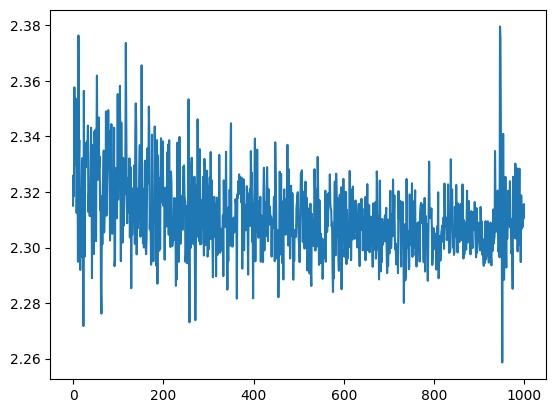

In [41]:
model = SimpleRNN(input_dim=10, hidden_dim=64, pin_length=4)

optimizer = optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()

batch_size = 32
seq_len = 50
loss_all = []

for epoch in range(1000):
    optimizer.zero_grad()

    # x, pin = generate_pin_sequence(seq_len=seq_len)
    x, pin = generate_batch(batch_size, seq_len, pin_length= 4)
    logits, _ = model(x)

    # Flatten for CrossEntropyLoss
    logits_flat = logits.view(-1, 10)   # [B*pin_length, 10]
    pin_flat = pin.view(-1)             # [B*pin_length]

    loss = loss_fn(logits_flat, pin_flat)
    loss_all.append(loss.item())

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

plt.plot(loss_all)
with torch.no_grad():
    x, pin = generate_pin_sequence(seq_len=50)
    logits, _ = model(x)
    predictions = logits.argmax(dim=-1)

print("True PIN:", pin)
print("Predicted:", predictions)


The goal here is to demonstrate one of the most important problems we face when using RNNs. In the above example, the length of the sequence of numbers provided was 50. Of those 50 numbers, only the first 4 are pin digits and the network needs to memorize those! You can see the unlike the first example, the loss is fluctuating! We can play around with the length of the sequence. For example, if there is no noisy digit, meaning there is no need for long term memory:

Play around with sequence length to see how it affects the final results. Look at loss and the final pin digits spilled out during testing

Epoch 0, Loss: 2.3023
Epoch 50, Loss: 2.3174
Epoch 100, Loss: 1.8801
Epoch 150, Loss: 1.7516
Epoch 200, Loss: 1.7719
Epoch 250, Loss: 1.9723
Epoch 300, Loss: 1.9162
Epoch 350, Loss: 1.9019
Epoch 400, Loss: 1.9303
Epoch 450, Loss: 1.8800
Epoch 500, Loss: 1.9243
Epoch 550, Loss: 1.9012
Epoch 600, Loss: 2.2421
Epoch 650, Loss: 2.1793
Epoch 700, Loss: 2.0024
Epoch 750, Loss: 2.0429
Epoch 800, Loss: 1.9844
Epoch 850, Loss: 2.0502
Epoch 900, Loss: 2.0306
Epoch 950, Loss: 1.9551
Epoch 1000, Loss: 2.0364
Epoch 1050, Loss: 1.9836
Epoch 1100, Loss: 2.1144
Epoch 1150, Loss: 2.0181
Epoch 1200, Loss: 1.9016
Epoch 1250, Loss: 2.6080
Epoch 1300, Loss: 2.0383
Epoch 1350, Loss: 1.8988
Epoch 1400, Loss: 1.7934
Epoch 1450, Loss: 1.8379
Epoch 1500, Loss: 2.0241
Epoch 1550, Loss: 1.8509
Epoch 1600, Loss: 2.4643
Epoch 1650, Loss: 1.9044
Epoch 1700, Loss: 1.8260
Epoch 1750, Loss: 1.8932
Epoch 1800, Loss: 1.8134
Epoch 1850, Loss: 1.8101
Epoch 1900, Loss: 1.8143
Epoch 1950, Loss: 1.9970
Epoch 2000, Loss: 1.937

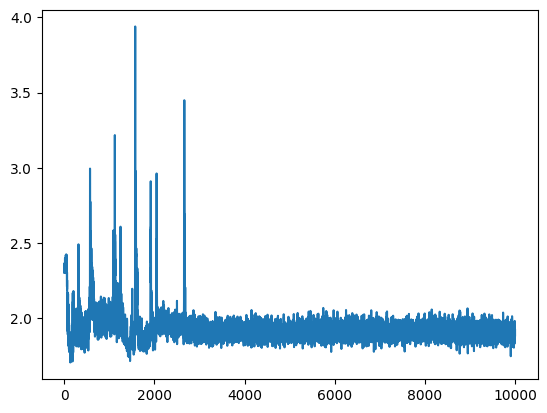

In [45]:
model = SimpleRNN(input_dim=10, hidden_dim=128, pin_length=4)

optimizer = optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()

batch_size = 32
seq_len = 20
loss_all = []
for epoch in range(10000):
    optimizer.zero_grad()

    # x, pin = generate_pin_sequence(seq_len=seq_len)
    x, pin = generate_batch(batch_size, seq_len, pin_length= 4)
    logits, _ = model(x)

    # Flatten for CrossEntropyLoss
    logits_flat = logits.view(-1, 10)   # [B*pin_length, 10]
    pin_flat = pin.view(-1)             # [B*pin_length]

    loss = loss_fn(logits_flat, pin_flat)
    loss_all.append(loss.item())

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

plt.plot(loss_all)
with torch.no_grad():
    x, pin = generate_pin_sequence(seq_len=seq_len)
    logits, _ = model(x)
    predictions = logits.argmax(dim=-1)

print("True PIN:", pin)
print("Predicted:", predictions)


But why is that?
For a vanilla RNN, the final output depends on the final hidden state $h_T$. And $h_T$ depends on $h_{T-1}$, which depends on $h_{T-2}$, … all the way back to early time steps where the PIN was presented.

So when you train, the **learning signal (the gradient)** has to travel backward through many recurrent steps.

That backward flow looks like repeated multiplication of matrices (and elementwise derivatives). Repeated multiplication is exactly where things can:

- shrink exponentially → **vanishing gradient**
- grow exponentially → **exploding gradient**

In a long-memory PIN task, the typical failure is **vanishing gradients**: the learning signal for early steps becomes tiny, so the model can’t learn a good “store and keep” strategy as the gap grows.

Mathematically:

RNN update:
$$h_t = tanh(W_hh_{t-1} + W_xx_t + b)$$
Assume the loss L depends on $h_T$ (because we decode the PIN from the final hidden state). And to update parameters that affect early time steps, we need gradients like $\frac{∂𝐿}{∂{h_t}}$ which by the chain rule:

$$\frac{∂𝐿}{∂{h_t}} = \frac{∂𝐿}{∂{h_T}}.\frac{∂{h_T}}{∂{h_{T-1}}}.\frac{∂h_{T-1}}{∂{h_{T-2}}}...\frac{∂h_{t+1}}{∂{h_{t}}}$$

That product is the whole story.
Each factor is a jacobian:

$$\frac{∂{h_k}}{∂{h_{k-1}}} = diag(1-tanh^2(a_k))W_h$$

and $|1-tanh^2(.)|≤1$

So when you multiply many of these together, the norm tends to shrink quickly unless conditions are just right. And the further back you need to go, the worse the problem gets. **That shrinkage is the vanishing gradient.**

Think of backprop through time like passing a message backward through a long chain of people. If each person passes along only 90% of the message, then after 100 people the message is basically gone. If each passes 110%, it blows up. **An RNN with long sequences is asking gradients to survive a long chain.**

In [46]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def plot_grad_through_time(model, batch_size = 32, seq_len=50, pin_length=4):
    model.train() # put the model in training mode
    x, pin = generate_batch(batch_size, seq_len, pin_length= pin_length)

    logits, h = model(x)
    # Tell PyTorch we want gradients for h (intermediate tensor)
    # NOTE that without using train_grad, and as default, 
    # only gradients for parameters are stored, never for intermediate steps
    # so in this case, the gradients for weight parameters are stored
    # so we have to explicitly say we want to "retain" gradients
    h.retain_grad()

    # Cross-entropy on 4 digits
    loss = F.cross_entropy(logits.view(-1, 10), pin.view(-1))
    model.zero_grad()
    loss.backward()

    # h.grad has shape [B, T, H]
    # this is a way to summarize
    # we will get the L2 norm across all H hidden units
    # we are computing the magnitude of the gradient vector at each time step, 
    # letting us see whether the learning signal survives back through time.
    grad_norm_t = h.grad.norm(dim=2).squeeze(0).detach().cpu().numpy()  # [T]

    plt.figure(figsize=(8, 3))
    plt.plot(grad_norm_t)
    plt.xlabel("Time step t")
    plt.ylabel(r"$\|\partial L / \partial h_t\|$")
    plt.title(f"Gradient reaching each time step (seq_len={seq_len})")
    plt.grid(True)
    plt.show()

    return grad_norm_t, loss.item()


Looking at the plots above, when $\|\partial L / \partial h_t\|$ for a time step/digit in sequence is 0:

- Almost no learning signal reaches time step t.
- That time step cannot learn to influence the loss.

And when it is large:
- That time step strongly affects the loss.
- Learning can adjust weights effectively.

We see:
- Large values near final time step T
- Exponentially smaller values as t moves earlier

That’s vanishing gradient made visible.

Here's a more detailed breakdown:

We derived that the gradient of the loss with respect to an earlier hidden state
is given by:

$$
\frac{\partial L}{\partial h_t}
=
J_{t+1}^\top
J_{t+2}^\top
\cdots
J_T^\top
\, g_T
$$

where

$$
g_T = \frac{\partial L}{\partial h_T}
$$

and each Jacobian term is:

$$
J_k
=
\frac{\partial h_k}{\partial h_{k-1}}
=
\mathrm{diag}(1 - h_k^2)\, W_h
$$

Thus, the gradient at time step $t$ is a product of many matrices:

$$
\frac{\partial L}{\partial h_t}
=
\left(
\prod_{k=t+1}^{T} J_k^\top
\right)
g_T
$$

If, on average,

$$
\| J_k \| \approx \alpha < 1
$$


then

$$
\left\|
\frac{\partial L}{\partial h_t}
\right\|
\approx
\alpha^{(T-t)}
\,
\| g_T \|
$$

which decays exponentially in the distance $(T - t)$.

This exponential decay of gradient magnitude as we move backward in time is known as the **vanishing gradient problem**.


So we need a way for gradients to flow backward without being multiplied repeatedly by shrinking terms.

In other words:

We need a path where gradients are preserved:

## LSTM

Long short term memory RNNs handle this using gates! Besides, unlike vanila RNNs, they have a long term memory component in addition to the short term memory ($h_{t-1} \rightarrow h_t$). To build an intuition, think of the long term memory as a conveyor belt (officially we call it Cell state). Information is put on the conveyor belt, at every step, the gates would determine what's to be forgotten (the forget gate), what incoming information is to be added to the conveyor belt (The input gate), and what part of the information on the conveyor belt is to be passed on to the output. 

To control this information flow, LSTMs use sigmoid and tanh functions. Sigmoids are used for gates (since they would constrain their outputs to between 0 and 1) while tanh output is always between -1 and 1 and can act as a valuing operation! 

### 1. Ingredients 
- $x_t$: The New Input (e.g., the current word you are reading).
- $h_{t-1}$: The Short-Term Memory (what happened just a moment ago - the same thing RNNs use).
- $C_{t-1}$: The Long-Term Memory (the "Cell State" that carries info across the whole sequence - the conveyor belt).

### 2. Forget gate
Determines what to toss out/discard. The first thing the LSTM does is look at the new input and the short-term memory to decide what part of the long-term memory is now irrelevant.

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

The Dot ($\cdot$): This is just a way of saying "multiply the inputs by their importance (weights).

"The Sigmoid ($\sigma$): It’s a function that squashes any number to a value between 0 and 1. If the result is 0, the gate "closes" (we forget this).If it’s 1, the gate "opens" (we keep this).

### 3. Input gate
What do we add to the conveyor belt. Now we decide what new information is worth saving for the long term. This happens in two parts.

- The Filter: $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$(Decides which values we’ll update).
- The New Info: $\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$(Creates a "candidate" vector of new information using tanh, which keeps values between -1 and 1).+1

### 4. Cell state: Updating the long term memory
Now we actually update the "conveyor belt" ($C_t$). We take the old memory, multiply it by the forget gate, and add the new information.

$$C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$$

- $f_t * C_{t-1}$: Old memory times the "forget" factor.
- $i_t * \tilde{C}_t$: New info times the "importance" factor.


### 5. Output gate
Finally, we need to decide what the "output" is for this specific moment. This becomes the new short-term memory ($h_t$).

- The Filter: $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$(Decides which parts of the long-term memory we want to show right now).
- The Output: $h_t = o_t * \tanh(C_t)$(We take our long-term memory, squash it with $\tanh$, and multiply it by our filter).

Why we use sigmoids for gates and tanh for valuing?

- The Sigmoid: The "Gatekeeper"The Sigmoid function $(\sigma)$ squashes any input value to a range between 0 and 1.Why 0 to 1? Because in math, multiplying by 0 makes things disappear, and multiplying by 1 keeps them exactly as they are.

The Job: It acts as a binary-ish switch. When the LSTM calculates a gate (Forget, Input, or Output), it uses Sigmoid to ask: "How much of this should I let through?" * 0.05 = "Mostly block this."0.98 = "Let almost all of it through."2. 

- The Tanh: The "Regulator"The Tanh function squashes values to a range between -1 and 1.Why -1 to 1? This is about centered data. If we only used Sigmoids (0 to 1), every time we added new information to our Long-Term Memory (the Cell State), the values would only ever go up. Over thousands of steps, the numbers would explode to infinity, crashing the model.

The Job: Tanh allows the model to increase OR decrease the memory.A positive value adds to the memory.A negative value "subtracts" or pushes the memory in the opposite direction.Crucially, it keeps the numbers from getting too big or too small, keeping the "math" stable.

## The Full LSTM Equations

## LSTM Equations

At each time step $t$, the LSTM computes the following:

**Forget gate**
$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

**Input gate**
$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

**Candidate memory**
$$
\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)
$$

**Cell State Update (Memory Highway)**
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

**Output Gate**
$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

**Hidden State**
$$
h_t = o_t \odot \tanh(c_t)
$$

---

### Key Components

- $x_t$ : input at time $t$
- $h_t$ : hidden state
- $c_t$ : cell state (long-term memory)
- $\sigma(\cdot)$ : sigmoid activation
- $\odot$ : element-wise multiplication
- $W_*, U_*$ : learnable weight matrices
- $b_*$ : learnable biases




In [47]:
class myLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, pin_length):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.pin_length = pin_length

        # Forget gate
        self.W_f = nn.Linear(input_dim, hidden_dim)
        self.U_f = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Input gate
        self.W_i = nn.Linear(input_dim, hidden_dim)
        self.U_i = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Candidate memory
        self.W_c = nn.Linear(input_dim, hidden_dim)
        self.U_c = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Output gate
        self.W_o = nn.Linear(input_dim, hidden_dim)
        self.U_o = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Final readout
        # NOTE that the outputs are one hot coded
        self.readout = nn.Linear(hidden_dim, pin_length * 10)

    def forward(self, x):

        B, T, D = x.shape

        c_t = torch.zeros(B, self.hidden_dim, device=x.device)
        h_t = torch.zeros(B, self.hidden_dim, device=x.device)

        h_all = []

        for t in range(T):
            x_t = x[:, t, :]

            f_t = torch.sigmoid(self.W_f(x_t) + self.U_f(h_t))
            i_t = torch.sigmoid(self.W_i(x_t) + self.U_i(h_t))
            c_tilde = torch.tanh(self.W_c(x_t) + self.U_c(h_t))

            c_t = f_t * c_t + i_t * c_tilde

            o_t = torch.sigmoid(self.W_o(x_t) + self.U_o(h_t))
            h_t = o_t * torch.tanh(c_t)

            h_all.append(h_t)

        h = torch.stack(h_all, dim=1)

        logits = self.readout(h[:, -1, :])
        logits = logits.view(B, self.pin_length, 10)

        return logits, h


In [48]:
model = myLSTM(input_dim=10, hidden_dim=64, pin_length=4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

batch_size = 32
seq_len = 20
loss_all = []
for step in range(10000):

    x, pin = generate_batch(seq_len=seq_len, batch_size=32, pin_length=4)

    logits, h = model(x)

    loss = loss_fn(
        logits.view(-1, 10),
        pin.view(-1)
    )

    loss_all.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 200 == 0:
        print("step:", step, "loss:", loss.item())


step: 0 loss: 2.303086280822754
step: 200 loss: 2.301196813583374
step: 400 loss: 2.294154644012451
step: 600 loss: 2.308424711227417
step: 800 loss: 2.311178684234619
step: 1000 loss: 2.3082048892974854
step: 1200 loss: 2.3041574954986572
step: 1400 loss: 2.296903371810913
step: 1600 loss: 2.299067974090576
step: 1800 loss: 2.300664186477661
step: 2000 loss: 2.3078866004943848
step: 2200 loss: 2.2990076541900635
step: 2400 loss: 2.3034448623657227
step: 2600 loss: 2.2962403297424316
step: 2800 loss: 2.3030736446380615
step: 3000 loss: 2.299893617630005
step: 3200 loss: 2.3035473823547363
step: 3400 loss: 2.304070234298706
step: 3600 loss: 2.3029723167419434
step: 3800 loss: 2.3050055503845215
step: 4000 loss: 2.309345245361328
step: 4200 loss: 2.302426338195801
step: 4400 loss: 2.3036398887634277
step: 4600 loss: 2.30484938621521
step: 4800 loss: 2.3077170848846436
step: 5000 loss: 2.301330327987671
step: 5200 loss: 2.306882381439209
step: 5400 loss: 2.300992965698242
step: 5600 loss:

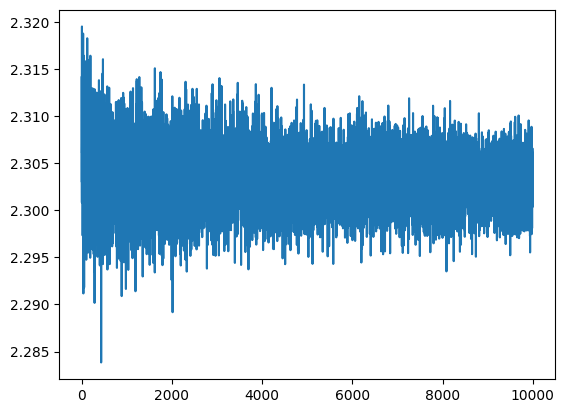

In [49]:
plt.plot(loss_all)

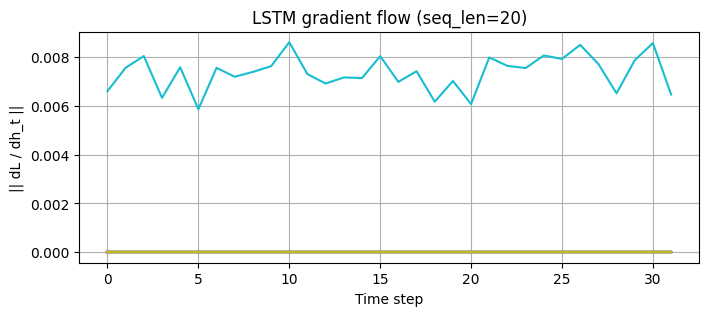

In [52]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def plot_grad_through_time_lstm(model, batch_size = 32, seq_len=200):

    x, pin = generate_batch(seq_len=seq_len, pin_length=4, batch_size=batch_size)

    logits, h = model(x)

    h.retain_grad()

    loss = F.cross_entropy(
        logits.view(-1, 10),
        pin.view(-1)
    )

    model.zero_grad()
    loss.backward()

    grad_norm_t = h.grad.norm(dim=2).squeeze(0).detach().cpu().numpy()

    plt.figure(figsize=(8, 3))
    plt.plot(grad_norm_t)
    plt.xlabel("Time step")
    plt.ylabel("|| dL / dh_t ||")
    plt.title(f"LSTM gradient flow (seq_len={seq_len})")
    plt.grid(True)
    plt.show()

    return grad_norm_t

_ = plot_grad_through_time_lstm(model, seq_len=20)


In [53]:
class LSTMPin(nn.Module):
    def __init__(self, input_dim, hidden_dim, pin_length):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.pin_length = pin_length

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.readout = nn.Linear(hidden_dim, pin_length * 10)

    def forward(self, x):
        # x: [B, T, D]

        output, (h_n, c_n) = self.lstm(x)

        # h_n is [1, B, H] since single layer
        h_last = h_n.squeeze(0)

        logits = self.readout(h_last)
        logits = logits.view(-1, self.pin_length, 10)

        return logits


In [54]:
model = LSTMPin(input_dim=10, hidden_dim=128, pin_length=4)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

seq_len = 20

batch_size = 32
loss_all = []
for step in range(5000):

    x, pin = generate_batch(batch_size, seq_len=seq_len, pin_length=4)
    # x, pin = generate_pin_sequence(seq_len=seq_len, pin_length=4)

    logits = model(x)

    loss = loss_fn(
        logits.view(-1, 10),
        pin.view(-1)
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_all.append(loss.item())

    if step % 500 == 0:
        with torch.no_grad():
            pred = logits.argmax(dim=-1)
            acc = (pred == pin).float().mean()
        print(f"step {step} | loss {loss.item():.4f} | acc {acc.item():.3f}")


step 0 | loss 2.3067 | acc 0.078
step 500 | loss 2.3085 | acc 0.102
step 1000 | loss 2.3039 | acc 0.102
step 1500 | loss 2.3074 | acc 0.078
step 2000 | loss 2.3031 | acc 0.109
step 2500 | loss 2.3014 | acc 0.156
step 3000 | loss 2.3018 | acc 0.133
step 3500 | loss 2.3008 | acc 0.109
step 4000 | loss 2.3037 | acc 0.078
step 4500 | loss 2.3051 | acc 0.094


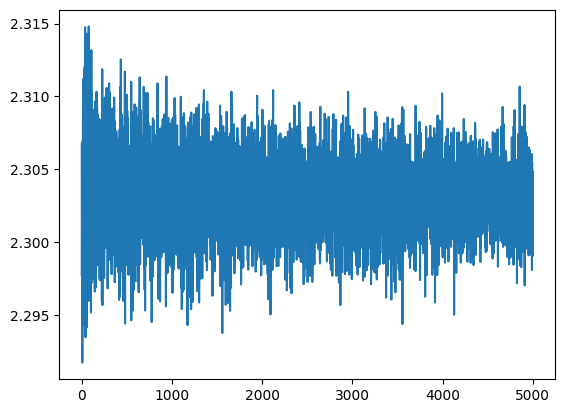

In [55]:
plt.plot(loss_all)